# Exercise 6.3

In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import os
import folium
import json

In [2]:
# propts matplotlib visuals to appear in notebook
%matplotlib inline

In [5]:
%matplotlib notebook

In [7]:
# Importing json file for US regions
regions_geo = r'C:/Users/jeffr/regions'

In [9]:
regions_geo

'C:/Users/jeffr/regions'

In [11]:
f = open(r'C:/Users/jeffr/regions',)
data = json.load(f)
for i in data['features']:
    print(i)

{'type': 'Feature', 'properties': {'name': 'Midwest'}, 'geometry': {'type': 'Polygon', 'coordinates': [[[-104.32617187499999, 49.03786794532644], [-103.974609375, 41.04621681452063], [-101.6015625, 41.04621681452063], [-102.48046875, 37.020098201368114], [-94.5703125, 37.09023980307208], [-93.603515625, 36.4566360115962], [-89.296875, 37.23032838760387], [-87.71484375, 38.272688535980976], [-85.4296875, 38.54816542304656], [-84.638671875, 39.16414104768742], [-83.232421875, 38.75408327579141], [-82.177734375, 38.685509760012], [-80.85937499999999, 39.842286020743394], [-80.595703125, 41.57436130598913], [-83.583984375, 41.96765920367816], [-82.79296874999999, 42.4234565179383], [-82.705078125, 43.389081939117496], [-83.232421875, 43.70759350405294], [-84.111328125, 43.96119063892024], [-83.49609375, 44.653024159812], [-84.55078125, 45.460130637921004], [-85.4296875, 45.1510532655634], [-86.396484375, 44.213709909702054], [-86.220703125, 43.389081939117496], [-86.220703125, 42.163403424

In [13]:
# Creating path
path = r'C:\Users\jeffr\Documents\Medical Costs Analysis'

In [15]:
# Importing data set
df = pd.read_csv(os.path.join(path, '02 Data', 'Prepared Data', 'insurance.csv'), index_col = False)

In [76]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,West,16884.92400
1,18,male,33.770,1,no,South,1725.55230
2,28,male,33.000,3,no,South,4449.46200
3,33,male,22.705,0,no,Midwest,21984.47061
4,32,male,28.880,0,no,Midwest,3866.85520


In [78]:
# Checking for NaN
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [80]:
# Checking for duplicates
dups = df.duplicated()

In [82]:
dups.shape

(1337,)

In [84]:
# Extreme values check for charges
sns.histplot(df['charges'], bins = 20, kde = True)

<Axes: xlabel='charges', ylabel='Count'>

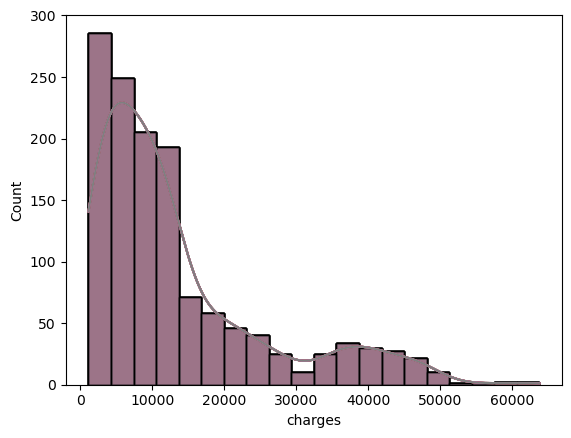

In [86]:
plt.show()

### Create a choropeth map using region variable

In [17]:
# Created data to plot on choropleth
data_to_plot = df[['region','charges']]
data_to_plot.head()

,region,charges
0,West,16884.92400
1,South,1725.55230
2,South,4449.46200
3,Midwest,21984.47061
4,Midwest,3866.85520


In [19]:
# Setup a folium map at a high-level zoom
map = folium.Map(location = [100, 0], zoom_start = 1.5)

# Creating choropleth map
folium.Choropleth(
    geo_data = regions_geo,
    data = data_to_plot,
    columns = ['region', 'charges'],
    key_on = 'feature.properties.name',
    fill_color = 'YlOrBr', fill_opacity=0.6, line_opacity=0.1,
    legend_name = "charges").add_to(map)
folium.LayerControl().add_to(map)
map

### Based on the choropleth mad, the MidWest region has the highest amount of medical charges while the Northeast, South, and West regions all have charges between 1,626 and 6,215. Although this analysis does answer my quesiton as to which region has the highest charges, it seems to be singled out as the other three regions all fall within the same range of charges. Why are the charges in this region so much higher than the others?  This is something I will be exploring in further analysis.

In [150]:
map.save('plot_data.html')